In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet('data/bitcoin_tweet.parquet')

### Data Analysis

In [3]:
df.describe()

,user_followers,user_friends,account_age_days,url_count
count,632179.0,632179.0,632179.000000,632179.000000
mean,4223.438121,768.950281,2555.759374,0.000321
std,53956.704763,2686.274589,1558.663658,0.017917
min,0.0,0.0,786.000000,0.000000
25%,40.0,93.0,1359.000000,0.000000
50%,163.0,270.0,1769.000000,0.000000
75%,786.0,742.0,3721.000000,0.000000
max,8076992.0,656204.0,6924.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 632179 entries, 16 to 4595426
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   user_name         632179 non-null  object             
 1   user_created      632179 non-null  datetime64[us, UTC]
 2   user_followers    632179 non-null  Int64              
 3   user_friends      632179 non-null  Int64              
 4   user_verified     632179 non-null  boolean            
 5   date              632179 non-null  datetime64[us, UTC]
 6   text              632179 non-null  object             
 7   hashtags          632178 non-null  object             
 8   mentions          632179 non-null  object             
 9   account_age_days  632179 non-null  int64              
 10  age_bucket        632179 non-null  category           
 11  url_count         632179 non-null  int64              
 12  text_clean        632179 non-null  object      

### Numerical column analysis

In [5]:
numerical_columns = df.select_dtypes(include=['int64', 'Int64']).columns.tolist()

In [6]:
df[numerical_columns].describe().loc[['min', 'max']].T

,min,max
user_followers,0.0,8076992.0
user_friends,0.0,656204.0
account_age_days,786.0,6924.0
url_count,0.0,1.0


- `account_age_days` has been pre processed (filtered by account age date to remove the new accounts) 
- `url_count` is engineered column that is grabbed from the text column (it has been capped at 1 to remove the **spam, ad** tweets)

#### Categorical column analysis

In [7]:
cat_columns = df.select_dtypes(include=['category', 'object']).columns.tolist()
cat_columns.remove('text')
cat_columns.remove('text_clean') # will analyse it later
cat_columns

['user_name', 'hashtags', 'mentions', 'age_bucket']

In [8]:
df.hashtags.str[0]

16             BTC
24             BTC
25             BTC
31         Bitcoin
51          cronje
            ...   
4595407       fiat
4595411    Bitcoin
4595422    bitcoin
4595425     Solana
4595426    Bitcoin
Name: hashtags, Length: 632179, dtype: object

In [9]:
df.age_bucket.value_counts()

age_bucket
3-5 yr     279370
>10 yr     162001
5-10 yr    144117
2-3 yr      46691
<2 yr           0
Name: count, dtype: int64

`account_age` with less than **2 years** has been removed during date pre-processing

### `hashtags` Analysis

In [10]:
hashtags_exploded = df['hashtags'].explode().reset_index(drop=True)
hashtag_counts = hashtags_exploded.str.lower().value_counts().reset_index()

print(f'total unique hashtags: {len(hashtag_counts):,}')

more_than_once = hashtag_counts[hashtag_counts['count'] > 1]
print(f'Total unique hashtags that have appeared more than once: {len(more_than_once):,}')
print("\nTop hashtags appearing more than once:")
hashtag_counts.head()

total unique hashtags: 34,164
Total unique hashtags that have appeared more than once: 12,020

Top hashtags appearing more than once:


,hashtags,count
0,bitcoin,465471
1,btc,233680
2,crypto,51301
3,eth,27724
4,ethereum,20270


From ~600k tweets there are 34k unique hashtags found

In [11]:
df_hashtag = df[["hashtags", "date"]].explode("hashtags")
df_hashtag["month"]    = df_hashtag["date"].dt.to_period("M")
df_hashtag["hashtags"] = df_hashtag["hashtags"].str.lower()
df_hashtag = df_hashtag[
    ~df_hashtag["hashtags"].str.contains("bitcoin|btc|crypto|eth", na=False)
]
df_hashtag = (
    df_hashtag
    .groupby(["month", "hashtags"])
    .size()
    .reset_index(name="count")
)
df_hashtag


C:\Users\batbi\AppData\Local\Temp\ipykernel_9084\2084700711.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_hashtag["month"]    = df_hashtag["date"].dt.to_period("M")


,month,hashtags,count
0,2025-03,000000000019d6689c085ae165831e934ff763ae46a2a6...,1
1,2025-03,100daychallenge,1
2,2025-03,100daysofcode,1
3,2025-03,100k,3
4,2025-03,10minutetournament,3
...,...,...,...
57258,2026-03,xlm,2
57259,2026-03,xmr,1
57260,2026-03,xrp,9
57261,2026-03,xrpl,1


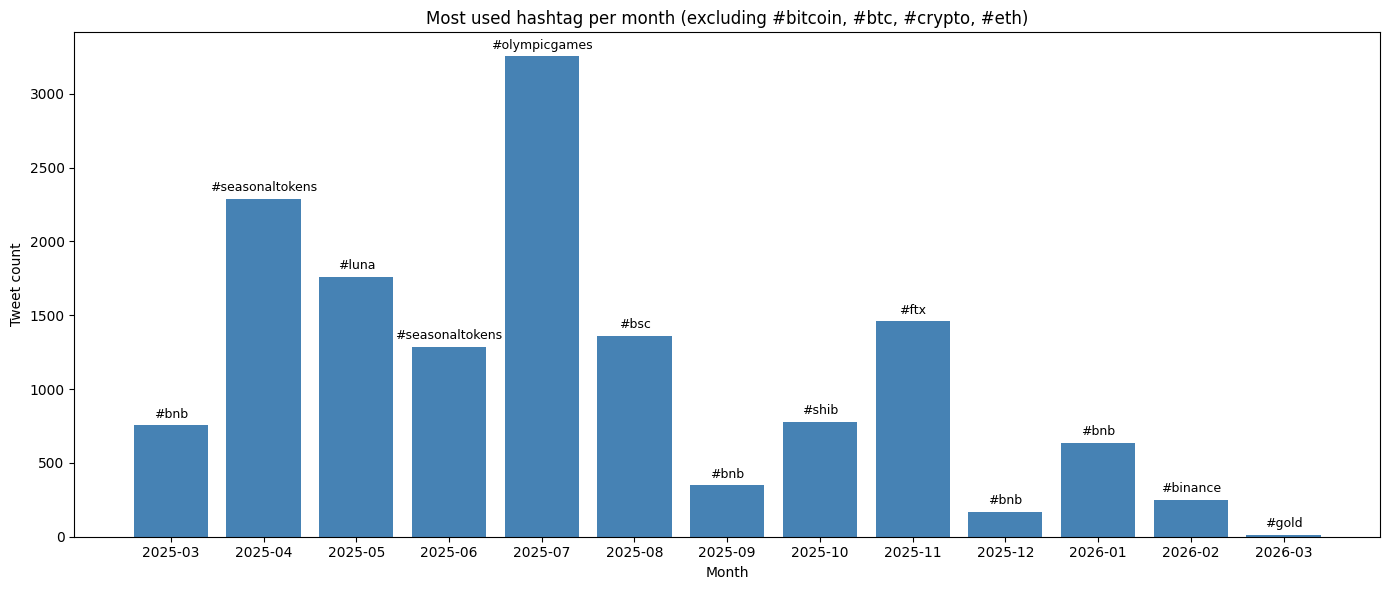

In [12]:
top_per_month = (
    df_hashtag
    .loc[df_hashtag.groupby("month")["count"].idxmax()]
    .sort_values("month")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(top_per_month["month"].astype(str), top_per_month["count"], color="steelblue")

cap = top_per_month["count"].max() * 0.01
for bar, tag in zip(bars, top_per_month["hashtags"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + cap,
            f"#{tag}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Month")
ax.set_ylabel("Tweet count")
ax.set_title("Most used hashtag per month (excluding #bitcoin, #btc, #crypto, #eth)")
plt.tight_layout()
plt.show()


### `user_name` Analysis

In [13]:
username_counts_df = df.user_name.value_counts()
username_counts_df.head(5)

user_name
Herry Mason                    99
Asher V.                       98
Crypto Advisor                 96
crypto spot                    95
500 headlines about bitcoin    94
Name: count, dtype: int64

During the pre processing we have removed accounts with **more than 100 tweets** (Bot account tweet, daily price news bot tweet)

In [14]:
for text in df[df.user_name == '500 headlines about bitcoin']['text'].head():
    print(text)

You might not see the need for money that can’t be counterfeited. But 1.4 billion Indians do. #bitcoin
The system is rigged. So we’re building one that can’t be. #bitcoin
Make your last overdraft your last. #bitcoin
Feel the rush of finally getting to agree with Marc Andreessen. #bitcoin
There’s no such thing as a blood bitcoin. #bitcoin


Some of the account with high tweet counts still seem to a bot account but we cannot remove the account with tweet volume cap

In [15]:
print(f"number of unique users: {df.user_name.nunique():,}")
print(df.user_name.value_counts().describe().loc[['min', '75%', 'max']].to_frame().T)

number of unique users: 227,205
       min  75%   max
count  1.0  2.0  99.0


most of the users (75%) only tweeted twice

In [16]:
print(f"95th percentile of users tweeted {df.user_name.value_counts().quantile(0.95)} times")

95th percentile of users tweeted 10.0 times


In [17]:
for text in df[df.user_name.isin(username_counts_df[username_counts_df == 2].index)]['text'].head(5):
    print(text)

@iamDonaldYusuf @yuzomausman @aproko_doctor Not now as there is fud of sub $30k #BTC ...people no wan risk buy at dz prices imo
Move Digital Energy Through Cyber Space. #Bitcoin #BTC
@MWCunfiltered If we went to 25K-27K rallied to 32k and chopped down back again that would be awful if you’re holding.  But maybe alts destroyed and #BTC at such an attractive price is what’s needed
Somebody please take #BTC behind the shed and put it out of its misery.
@TTGMaverick I will examine your theory of being highs on Wednesday. Unfortunately, #btc is now coincide with the movement of #SPX.


most of them are **replied** or **mentioned** someone of their tweet. which is great for **social graph** also this means **all human/non-bot** tweets which is great for sentiment analysis

#### `Mentions` exploration

In [18]:
mentions_exploded = df.mentions.explode()

In [19]:
mentions_exploded.value_counts().head()

mentions
elonmusk           11821
saylor              9472
peterschiff         7564
cz_binance          4817
bitcoinmagazine     4743
Name: count, dtype: int64

there are 2 people mentioned the most (other than elonmusk). might be useful for social graph

In [20]:
for text in df[(df.user_name =='saylor')]['text'].head():
    print(text)

i told you all yesterday to buy the #Bitcoin  dip

did you do it?

probably not... 

BUT there is still hope for you

you can still mortgage your house and buy bitcoin

you can still sell your clothes and buy bitcoin

you can still live on the poverty line... and buy bitcoin
@smolleader @smolEggOpinion this is the correct way of going about it, if you have anything else left to sell I suggest doing that and buying more #Bitcoin
they say that smols have topped

they said the same thing about #Bitcoin in 2011, 2013 and 2017 

i think im noticing a pattern here
i really think a16z should just buy #bitcoin with leverage and just send it
looking for a job after the events of today if anyone needs a good boat captain im available to steer the ship #Bitcoin


He seems to be very active in twitter in bitcoin community

**peterschiff** (american stockbroker) and **elon musk** and the other 2 did not appear in the clean or the initial dataset\
so `saylor` is probably the most popular/communicative one in bitcoin community

# Network Building

## Hashtag Co-occurrence Network

it is an undirected, weighted network where **nodes represent hashtags** 
and **edges connect hashtags that appear together in the same tweet**. Edge weight 
reflects the number of tweets in which the two hashtags co-occurred, meaning a higher 
weight indicates a stronger topical association.

In [21]:
from itertools import combinations
import ast

def parse_hashtags(h):
    if isinstance(h, str):
        try:
            h = ast.literal_eval(h)
        except:
            return []
    try:
        return [str(tag).lower().strip() for tag in h]
    except:
        return []

df["hashtag_list"] = df["hashtags"].apply(parse_hashtags)
df[['hashtags', 'hashtag_list']]


,hashtags,hashtag_list
16,[BTC],[btc]
24,[BTC],[btc]
25,[BTC],[btc]
31,"[Bitcoin, BTC]","[bitcoin, btc]"
51,"[cronje, frognation, BTC]","[cronje, frognation, btc]"
...,...,...
4595407,"[fiat, Bitcoin, Cryptos, censorship, Resistance]","[fiat, bitcoin, cryptos, censorship, resistance]"
4595411,"[Bitcoin, Crypto]","[bitcoin, crypto]"
4595422,[bitcoin],[bitcoin]
4595425,"[Solana, MATIC, Ada, Bitcoin]","[solana, matic, ada, bitcoin]"


#### Build all (tag1, tag2) pairs per tweet then aggregate


In [22]:
df_co = (
    df[df["hashtag_list"].apply(len) >= 2]
    .assign(pairs=lambda x: x["hashtag_list"].apply(
        lambda tags: list(combinations(sorted(set(tags)), 2))
    ))
    .explode("pairs")
    .dropna(subset=["pairs"])
)

co_occurrences = (
    df_co
    .assign(tag1=df_co["pairs"].apply(lambda p: p[0]),
            tag2=df_co["pairs"].apply(lambda p: p[1]))
    .groupby(["tag1", "tag2"])
    .size()
    .reset_index(name="weight")
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)

print(f"Tweets with 2+ hashtags: {(df['hashtag_list'].apply(len) >= 2).sum():,}")
print(f"Unique co-occurrence pairs: {len(co_occurrences):,}")
print("\nTop 10 pairs:")
co_occurrences.head(10)

Tweets with 2+ hashtags: 280,338
Unique co-occurrence pairs: 145,426

Top 10 pairs:


,tag1,tag2,weight
0,bitcoin,btc,49190
1,bitcoin,crypto,34730
2,btc,crypto,23832
3,btc,eth,22042
4,bitcoin,ethereum,16122
5,bitcoin,cryptocurrency,15243
6,btc,cryptocurrency,9393
7,bitcoin,eth,8126
8,bnb,btc,7004
9,btc,ethereum,5837


#### Check distribution


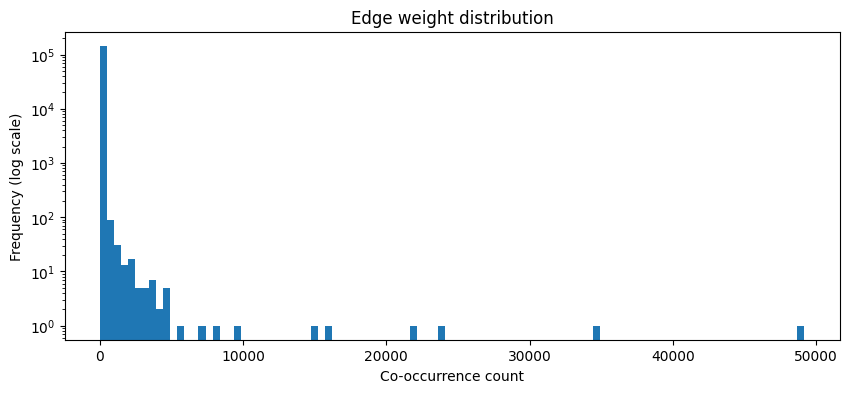

In [23]:
plt.figure(figsize=(10, 4))
plt.hist(co_occurrences["weight"], bins=100, log=True)
plt.xlabel("Co-occurrence count")
plt.ylabel("Frequency (log scale)")
plt.title("Edge weight distribution")
plt.show()

In [24]:
import networkx as nx

MIN_WEIGHT = 50  # pairs that co-occurred at least 50 times
co_filtered = co_occurrences[co_occurrences["weight"] >= MIN_WEIGHT]

G = nx.from_pandas_edgelist(co_filtered, source="tag1", target="tag2", edge_attr="weight")

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Is connected: {nx.is_connected(G)}")

largest_cc = max(nx.connected_components(G), key=len)
G_main = G.subgraph(largest_cc).copy()
print(f"Largest component nodes: {G_main.number_of_nodes()}")
print(f"Average clustering coefficient: {nx.average_clustering(G_main):.4f}")
print(f"Average shortest path length: {nx.average_shortest_path_length(G_main):.4f}")


Nodes: 612
Edges: 1634
Density: 0.0087
Is connected: False
Largest component nodes: 605
Average clustering coefficient: 0.6309
Average shortest path length: 2.1375


### Network Properties

The filtered graph (minimum co-occurrence weight ≥ 50) contains **612 nodes and \
1,634 edges** with a density of **0.0087**, confirming the network is sparse.\
Most hashtags co-occur only with a small subset of others.

The **average clustering coefficient of 0.631** is notably high, meaning that\
neighbours of a node tend to also be connected to each other. This suggests the\
Bitcoin Twitter conversation forms tight topical clusters rather than a random 
mix of hashtags.

The **average shortest path length of 2.14** across the largest connected\
component (605 nodes) indicates a small-world structure. Any two hashtags in\
the network are on average only ~2 hops apart, meaning topics are closely 
interconnected despite the sparse overall density.

In [25]:
# Degree centrality: how many connections does each hashtag have
degree_cent = nx.degree_centrality(G_main)

# Betweenness centrality: which hashtags bridge different communities
between_cent = nx.betweenness_centrality(G_main, weight='weight')

# PageRank: based on incooming links
pagerank = nx.pagerank(G_main, weight='weight')

# Weighted degree (strength): total weight of all connections
strength = dict(G_main.degree(weight='weight'))

centrality_df = pd.DataFrame({
    'hashtag': list(degree_cent.keys()),
    'degree_centrality': list(degree_cent.values()),
    'betweenness_centrality': [between_cent[n] for n in degree_cent.keys()],
    'pagerank': [pagerank[n] for n in degree_cent.keys()],
    'strength': [strength[n] for n in degree_cent.keys()]
}).sort_values('pagerank', ascending=False)

centrality_df.head(20)

,hashtag,degree_centrality,betweenness_centrality,pagerank,strength
0,bitcoin,0.834437,0.596391,0.219167,282916
1,btc,0.632450,0.435058,0.160616,228981
2,crypto,0.223510,0.070443,0.067029,107424
3,eth,0.132450,0.038255,0.033749,55829
5,cryptocurrency,0.109272,0.033653,0.027076,43856
4,ethereum,0.110927,0.032394,0.025847,41921
6,bnb,0.091060,0.035554,0.015409,23987
16,bsc,0.071192,0.013925,0.012041,17602
8,binance,0.066225,0.019943,0.010617,16847
11,blockchain,0.052980,0.008066,0.008151,12390


### Centrality Analysis

Four centrality measures were computed to identify the most important nodes:

- **Degree centrality** measures how many unique hashtags a given hashtag co-occurs with. `#bitcoin` (0.834) and `#btc` (0.632) dominate, confirming\
  they act as universal connectors in the network.

- **Betweenness centrality** identifies hashtags that serve as bridges between different parts of the network. `#bitcoin` (0.596) scores significantly higher\
  than any other node, meaning removing it would fragment the network more than removing any other hashtag.

- **PageRank** accounts for the importance of a node's neighbours, not just connection count. The top PageRank nodes (`#bitcoin`, `#btc`, `#crypto`) are\
  consistent with degree rankings, suggesting the core of the network is genuinely dominant rather than artificially inflated by weak connections.

- **Strength** (weighted degree) confirms that `#bitcoin` and `#btc` have by far the highest total co-occurrence volume,\
  reflecting their role as the universal anchors of Bitcoin-related conversation.

## Detect communities

In [26]:
from community import community_louvain

partition = community_louvain.best_partition(G_main, weight='weight', random_state=0)
df_partition = pd.DataFrame(partition.items(), columns=['Node', 'Community'])

df_partition.groupby('Community')['Node'].unique()

Community
0     [bitcoin, crypto, ethereum, cryptocurrency, do...
1                           [eumwallet, eum, walleteum]
2     [cryptomining, seasonaltokens, cyclicalinvesti...
3     [binance, bsc, defi, nfts, binancesmartchain, ...
4                             [staking, betfurysuccess]
5     [luna, ust, terra, terraluna, lunacrash, lunat...
6                     [feg, fegex, fegtoken, smartdefi]
7                                [revenuecoin, revenue]
8                             [libonomy, interoperable]
9     [covid19, covidvaccine, covid, getvaccinated, ...
10                  [lmoon, releasethekraken, longmoon]
11                               [pnpcoin, helios, pnp]
12      [legitcommunity, liquidchain, xlc, tomo, tomoe]
13                    [litho, lep100token, lithosphere]
14                       [charity, thc, transhumancoin]
15                          [robinhood, nintcoin, nint]
16                               [algotrade, stewiebot]
17                                    

**21 communities** found with random state 0

#### Rank the nodes within each community using a pagerank dictionary.
- it shows the `10 most influential` hashtags in each community

In [27]:
nx.set_node_attributes(G_main, partition, "community")

df_partition["pagerank"] = df_partition["Node"].map(pagerank)

top_per_community = (
    df_partition
    .sort_values("pagerank", ascending=False)
    .groupby("Community", sort=True)
    .agg(size=('Node', 'count'), top_hashtags=('Node', lambda x: list(x.head(10))))
    .reset_index()
)

for _, row in top_per_community.iterrows():
    print(f"\nCommunity {row.Community} ({row['size']} hashtags):")
    print("  Top hashtags:", row.top_hashtags)



Community 0 (293 hashtags):
  Top hashtags: ['bitcoin', 'crypto', 'cryptocurrency', 'ethereum', 'blockchain', 'dogecoin', 'cryptocrash', 'cryptocurrencies', 'altcoins', 'hodl']

Community 1 (3 hashtags):
  Top hashtags: ['eumwallet', 'eum', 'walleteum']

Community 2 (7 hashtags):
  Top hashtags: ['cryptomining', 'seasonaltokens', 'cyclicalinvesting', 'cyclicallnvesting', 'seasonal', 'seasonaltoken', 'cyclicalinvestment']

Community 3 (39 hashtags):
  Top hashtags: ['bsc', 'binance', 'defi', 'nfts', 'binancesmartchain', 'ikonic', 'hyperburnprotocol', 'hyperburn', 'pancakeswap', 'ido']

Community 4 (2 hashtags):
  Top hashtags: ['staking', 'betfurysuccess']

Community 5 (8 hashtags):
  Top hashtags: ['luna', 'ust', 'terra', 'terraluna', 'bnbchain', 'ampleswap', 'lunatics', 'lunacrash']

Community 6 (4 hashtags):
  Top hashtags: ['feg', 'fegex', 'fegtoken', 'smartdefi']

Community 7 (2 hashtags):
  Top hashtags: ['revenuecoin', 'revenue']

Community 8 (2 hashtags):
  Top hashtags: ['libo

In [28]:
top_per_community.sort_values(by='size',ascending=False)

,Community,size,top_hashtags
0,0,293,"[bitcoin, crypto, cryptocurrency, ethereum, bl..."
18,18,210,"[btc, eth, bnb, nft, xrp, doge, ada, shib, sol..."
3,3,39,"[bsc, binance, defi, nfts, binancesmartchain, ..."
5,5,8,"[luna, ust, terra, terraluna, bnbchain, amples..."
2,2,7,"[cryptomining, seasonaltokens, cyclicalinvesti..."
9,9,7,"[covidvaccine, covid19, covid, getvaccinated, ..."
12,12,5,"[legitcommunity, xlc, liquidchain, tomoe, tomo]"
6,6,4,"[feg, fegex, fegtoken, smartdefi]"
1,1,3,"[eumwallet, eum, walleteum]"
15,15,3,"[robinhood, nintcoin, nint]"


In [29]:
df_luna = df[['date','text','hashtags']]
df_luna = df_luna.explode('hashtags')

In [30]:
df_luna[df_luna.hashtags.isin(['luna', 'ust', 'terra', 'terraluna', 'bnbchain', 'ampleswap', 'lunatics', 'lunacrash'])].drop_duplicates(subset='date')

,date,text,hashtags
3686,2025-03-06 18:36:32+00:00,@LendeXeFinance @iota @assembly_net #ust is al...,ust
5443,2025-03-06 20:30:13+00:00,@CryptoWizardd This supports my 40s level #lun...,luna
10894,2025-03-07 04:19:21+00:00,Crypto market shows significant downtrend. All...,luna
26001,2025-03-07 18:10:01+00:00,"Nice dip #btc gonna buy again, hehe\n\n#luna",luna
37246,2025-03-09 11:56:06+00:00,Odd to see an alt coin like @terra_money make ...,terraluna
...,...,...,...
4547299,2026-02-17 15:47:38+00:00,@CryptoQueb Adopting crypto will help them. Y...,ust
4555055,2026-02-17 21:12:39+00:00,Ok #cryptotwitter #CT what should I buy this d...,luna
4557203,2026-02-17 23:37:58+00:00,Crypto volatility dips are a blessing for new ...,terra
4590803,2026-03-02 20:14:31+00:00,$LUNA seems to have an overbought pattern on 1...,ust


In [31]:
df_luna[df_luna.hashtags.isin(['covidvaccine', 'covid19', 'covid', 'getvaccinated', 'deltavariant', 'vaccine', 'vaccinated'])].drop_duplicates(subset='text')


,date,text,hashtags
430021,2025-04-15 09:15:47+00:00,@MMCrypto #covid-19 since 2019\n#inflation\n#w...,covid
526772,2025-04-18 07:15:43+00:00,@sayalhumdililah @JesseOlson @newsforextrader ...,covid19
841105,2025-05-01 12:57:10+00:00,Maybe it’s time to read some forbidden books. ...,covid
1041393,2025-05-23 23:56:25+00:00,@DmodosCutter @EnemyInAState @JudeJack @ELHopk...,covid
1412622,2025-06-21 10:26:41+00:00,"Listen, if #China wants to fold, let them. \n\...",covid
...,...,...,...
4209914,2026-01-09 23:27:17+00:00,@healthbyjames They steal half your income wit...,covid
4221278,2026-01-11 23:30:35+00:00,@theo_crypto99 What if he is right? 🤷‍♂️🤣\n\n#...,vaccine
4291205,2026-01-13 17:39:57+00:00,CDC now says bulls have Covid and just need to...,covid
4396162,2026-01-22 01:00:14+00:00,The same day Ireland lifts nearly all #covid r...,covid


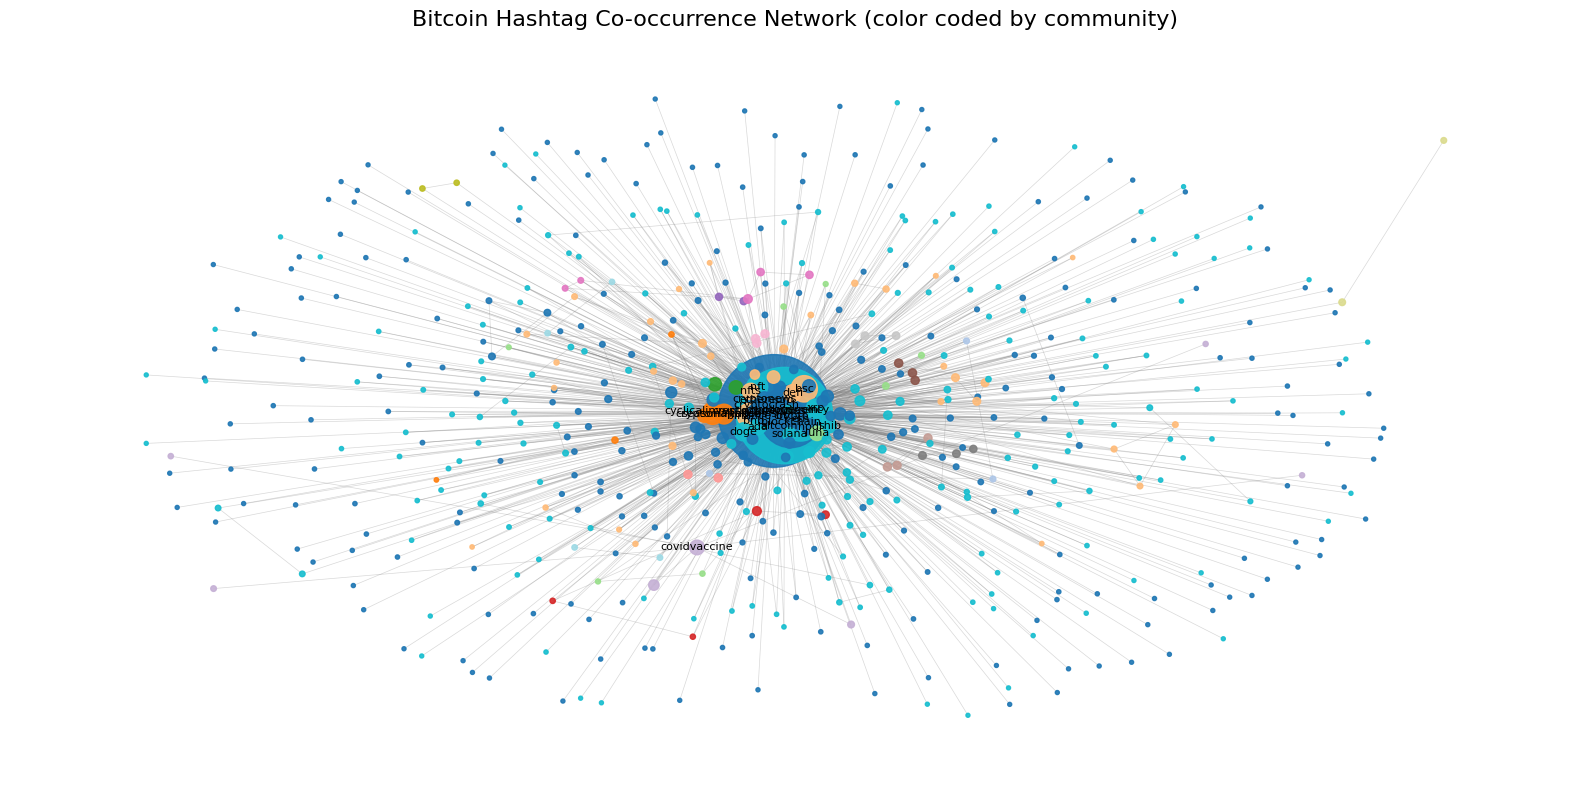

In [32]:
import matplotlib.cm as cm

plt.figure(figsize=(16, 8))

# Layout
pos = nx.spring_layout(G_main, weight='weight', seed=42, k=2)

# Colour by community
num_communities = len(set(partition.values()))
colours = cm.tab20(np.linspace(0, 1, num_communities))
node_colours = [colours[partition[node]] for node in G_main.nodes()]

# Size by pagerank
node_sizes = [pagerank[node] * 30000 for node in G_main.nodes()]

# Edge width by weight
edge_weights = [G_main[u][v]['weight'] for u, v in G_main.edges()]
max_w = max(edge_weights)
edge_widths = [0.5 + 3 * (w / max_w) for w in edge_weights]

nx.draw_networkx_edges(G_main, pos, width=edge_widths, alpha=0.3, edge_color='grey')
nx.draw_networkx_nodes(G_main, pos, node_color=node_colours, node_size=node_sizes, alpha=0.9)

# Label only the top nodes so it doesn't get cluttered
top_nodes = centrality_df.head(30)['hashtag'].tolist()
labels = {n: n for n in G_main.nodes() if n in top_nodes}
nx.draw_networkx_labels(G_main, pos, labels, font_size=8)

plt.title('Bitcoin Hashtag Co-occurrence Network (color coded by community)', fontsize=16)
plt.axis('off')
plt.tight_layout()
#plt.savefig('network.png', dpi=150, bbox_inches='tight')
plt.show()

### Community Detection (Louvain)

Louvain modularity optimisation identified **21 communities** in the hashtag 
network. The majority of communities are small niche clusters (2–8 nodes) 
representing specific projects or events, while two communities dominate:

| Community | Size | Character |
|---|---|---|
| 0 | 293 hashtags | **General crypto discourse** (Bitcoin, Ethereum, altcoins, DeFi broadly) |
| 18 | 210 hashtags | **Ticker-driven trading** (BTC, ETH, BNB, XRP, DOGE, ADA by symbol) |
| 3 | 39 hashtags | **BSC/Binance ecosystem** ( DeFi protocols, BSC-native tokens) |
| 5 | 8 hashtags | **Terra/LUNA collapse** (a time-specific crisis cluster) |
| 9 | 7 hashtags | **COVID-Bitcoin intersection** v(accine discourse mixed with BTC )|
| 2 | 7 hashtags | **Crypto mining / seasonal investing** niche |

The isolation of the Terra/LUNA collapse (Community 5) into its own cluster is 
particularly noteworthy. It reflects a real-world event (the May 2022 LUNA 
crash https://www.forbes.com/sites/qai/2022/09/20/what-really-happened-to-luna-crypto/) creating a distinct conversational sphere that intersects with but remains\
separate from general Bitcoin discussion. Similarly, the COVID-Bitcoin cluster (Community 9) suggests a subset of users who discuss cryptocurrency in the\
context of pandemic-era monetary policy.

# `Mentions` network analysis
Remove tweets are **mention spammed** constantly
- **Signal**: many mentions + very few followers + mentions contain exchange/project names

In [33]:
EXCHANGE_ACCOUNTS = [
    'mexc_fans', 'mexc_updates', 'mexcresearch', 'binance', 
    'kucoin', 'bybit_official', 'coinbase', 'okx'
]

def is_mention_spam(row):
    mentions = row['mentions']
    if isinstance(mentions, str):
        try:
            mentions = ast.literal_eval(mentions)
        except:
            return False
    
    if not isinstance(mentions, list):
        return False
        
    # Flag if mentions contain known exchange accounts
    has_exchange = any(m.lower() in EXCHANGE_ACCOUNTS for m in mentions)
    
    # Flag if too many mentions from low follower account
    too_many_mentions = len(mentions) >= 4 and row['user_followers'] < 100
    
    return has_exchange or too_many_mentions

df_mention = df[~df.apply(is_mention_spam, axis=1)]
df_mention

,user_name,user_created,user_followers,user_friends,user_verified,date,text,hashtags,mentions,account_age_days,age_bucket,url_count,text_clean,hashtag_list
16,Alal,2022-02-25 04:30:38+00:00,17,179,False,2025-03-06 14:43:39+00:00,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,[BTC],"[mexcresearch, mexc_fans, mexc_updates, alnahy...",1104,3-5 yr,0,- 39000$ This is so amazing. I am impressed wi...,[btc]
24,Bottle🐐,2015-02-19 08:11:45+00:00,527,307,False,2025-03-06 14:44:05+00:00,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,[BTC],"[iamdonaldyusuf, yuzomausman, aproko_doctor]",3667,>10 yr,0,Not now as there is fud of sub $30k ...people ...,[btc]
25,LowCapVillain,2021-12-30 00:19:52+00:00,108,31,False,2025-03-06 14:44:09+00:00,I personally ignore weekend moves and chill wi...,[BTC],[],1161,3-5 yr,0,I personally ignore weekend moves and chill wi...,[btc]
31,Millennial Wealth,2021-08-26 00:26:37+00:00,24,86,False,2025-03-06 14:44:23+00:00,Move Digital Energy Through Cyber Space. #Bitc...,"[Bitcoin, BTC]",[],1287,3-5 yr,0,Move Digital Energy Through Cyber Space.,"[bitcoin, btc]"
51,Crypto Don,2020-03-19 17:04:42+00:00,180,908,False,2025-03-06 14:46:23+00:00,"1/2 End of shitcoin season, lasted even longer...","[cronje, frognation, BTC]",[],1812,3-5 yr,0,"1/2 End of shitcoin season, lasted even longer...","[cronje, frognation, btc]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595407,COLDSPACE,2021-07-16 23:03:54+00:00,32,403,False,2026-03-02 23:59:27+00:00,@MartiniGuyYT All you need is an internet conn...,"[fiat, Bitcoin, Cryptos, censorship, Resistance]",[martiniguyyt],1328,3-5 yr,0,All you need is an internet connection and a w...,"[fiat, bitcoin, cryptos, censorship, resistance]"
4595411,Crypto Geek,2022-02-28 23:34:18+00:00,4,23,False,2026-03-02 23:59:31+00:00,@lexfridman @saylor 1. How can #Bitcoin become...,"[Bitcoin, Crypto]","[lexfridman, saylor]",1101,3-5 yr,0,1. How can become a global currency for every ...,"[bitcoin, crypto]"
4595422,Hodlers Journey 🍁 ⚡️,2021-04-08 18:39:21+00:00,236,1126,False,2026-03-02 23:59:49+00:00,@jkenney Now eliminate the debt and add #bitco...,[bitcoin],[jkenney],1427,3-5 yr,0,Now eliminate the debt and add to the Provinci...,[bitcoin]
4595425,Blessed Mom of 3 kiddos~I 💗 them so much~🕊️🥀,2011-06-07 14:40:15+00:00,336,878,False,2026-03-02 23:59:52+00:00,@TheMoonCarl #Solana #MATIC maybe #Ada but if ...,"[Solana, MATIC, Ada, Bitcoin]",[themooncarl],5020,>10 yr,0,maybe but if probably put it into,"[solana, matic, ada, bitcoin]"


### Build mention edge list

In [34]:
df_mention = df_mention[["user_name", "mentions"]]

df_mentions_exploded = df_mention.explode("mentions")

# Drop rows where a user had no mentions
df_exploded = df_mentions_exploded.dropna(subset=["mentions"])
df_exploded


,user_name,mentions
16,Alal,mexcresearch
16,Alal,mexc_fans
16,Alal,mexc_updates
16,Alal,alnahyanprince1
16,Alal,apnahyan2
...,...,...
4595407,COLDSPACE,martiniguyyt
4595411,Crypto Geek,lexfridman
4595411,Crypto Geek,saylor
4595422,Hodlers Journey 🍁 ⚡️,jkenney


In [35]:
# Normalise casing and drop self-mentions
df_exploded = df_exploded.copy()
df_exploded["user_name"] = df_exploded["user_name"].str.lower().str.strip()
df_exploded["mentions"]  = df_exploded["mentions"].str.lower().str.strip()
df_exploded = df_exploded[df_exploded["user_name"] != df_exploded["mentions"]]

# Count how many times each (user -> mentioned_user) pair appears
df_mentions_exploded = (
    df_exploded
    .groupby(["user_name", "mentions"], sort=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print(f"Unique mention pairs: {len(df_mentions_exploded):,}")
df_mentions_exploded.head()


Unique mention pairs: 416,413


,user_name,mentions,count
291076,hamidreza,binance,186
291074,hamidreza,fegtoken,179
290917,abbas khoda,binance,164
290915,abbas khoda,fegtoken,140
290968,ali,binance,136


In [36]:
G_mention = nx.from_pandas_edgelist(
    df_mentions_exploded,
    source="user_name",
    target="mentions",
    edge_attr="count",
    create_using=nx.DiGraph()
)

print(f"Nodes: {G_mention.number_of_nodes():,}")
print(f"Edges: {G_mention.number_of_edges():,}")


Nodes: 220,026
Edges: 416,413


In [37]:
# Top mentioned users by total incoming mention weight
df_mentions_exploded.groupby("mentions")["count"].sum().sort_values(ascending=False).head(10)


mentions
elonmusk           11821
saylor              9472
peterschiff         7564
cz_binance          4817
bitcoinmagazine     4743
btc_archive         4531
themooncarl         4240
binance             3752
jack                3562
apompliano          3457
Name: count, dtype: int64

In [38]:
G = nx.from_pandas_edgelist(
    df_mentions_exploded,
    source='user_name',
    target='mentions',
    edge_attr='count',
    create_using=nx.Graph()
)


In [39]:
centrality_mention = (
    pd.DataFrame(nx.degree_centrality(G).items(), columns=["user", "centrality"])
    .sort_values("centrality", ascending=False)
    .reset_index(drop=True)
)
centrality_mention.head(10)


,user,centrality
0,elonmusk,0.039268
1,saylor,0.031378
2,peterschiff,0.023579
3,bitcoinmagazine,0.016634
4,btc_archive,0.016107
5,cz_binance,0.015007
6,themooncarl,0.014162
7,jack,0.012930
8,apompliano,0.012821
9,michael_saylor,0.010949


Top `centrality` scores are around **0.039** and **0.031**, it means these accounts are connected to roughly **3.9%** and **3.1%** of every single user present in the dataset.

In [40]:
df_heavy = df_mentions_exploded[df_mentions_exploded['count'] > 5]

G_light = nx.from_pandas_edgelist(df_heavy, 'user_name', 'mentions', edge_attr='count')

giant = max(nx.connected_components(G_light), key=len)
G_final = G_light.subgraph(giant).copy()

In [41]:
from pyvis.network import Network

net = Network(notebook=True, cdn_resources="in_line",
              width="1000px", height="700px", bgcolor="#222222", font_color="white")
net.from_nx(G_final)
net.show("G_filtered.html")

G_filtered.html


In [42]:
in_degree_df = (
    pd.DataFrame(G_mention.in_degree(weight="count"), columns=["user", "in_degree"])
    .sort_values("in_degree", ascending=False)
    .reset_index(drop=True)
)
print("Most mentioned users:")
print(in_degree_df.head(20).to_string(index=False))


Most mentioned users:
           user  in_degree
       elonmusk      11821
         saylor       9472
    peterschiff       7564
     cz_binance       4817
bitcoinmagazine       4743
    btc_archive       4531
    themooncarl       4240
        binance       3752
           jack       3562
     apompliano       3457
       rovercrc       3395
 michael_saylor       3132
  thecryptolark       2614
    watcherguru       2143
    nayibbukele       2088
      maxkeiser       1909
 altcoindailyio       1875
intocryptoverse       1737
       mmcrypto       1731
        danheld       1708


## `User Mention` Network

We have constructed a **directed, weighted network** where nodes represent **Twitter users** 
and a directed edge from user A to user B indicates that A **mentioned** B in a tweet.\
Edge weight represents the total number of times A **mentioned** B.

Unlike the hashtag network which reveals topical communities, the mention network 
reveals the **social structure** of Bitcoin Twitter.\
Like who are the **authoritative** voices, who are the **broadcasters**, and how information flows between users.

### **Most Mentioned Users**

The top mentioned accounts reveal a clear hierarchy of influence in Bitcoin 
Twitter discourse:

| User | In-degree | Role |
|---|---|---|
| @elonmusk | 11,821 | Market-moving figure, general public interest |
| @saylor | 9,472 | MicroStrategy CEO, Bitcoin maximalist |
| @peterschiff | 7,564 | Known Bitcoin sceptic (mentioned in debate) |
| @cz_binance | 4,817 | Binance CEO (exchange authority) |
| @bitcoinmagazine | 4,743 | Media/information authority |
| @btc_archive | 4,531 | Historical Bitcoin content curator |
| @themooncarl | 4,240 | Crypto influencer |
| @jack | 3,562 | Twitter/Square founder, Bitcoin advocate |

Notably, @peterschiff's high mention count despite being a Bitcoin *sceptic* suggests that a\
significant portion of Bitcoin Twitter discussion is *argumentative*. like users mention him\
to debate or rebut his views.

## Individual Extended Network Analysis

## K-Core Decomposition

K-core peels the network layer by layer, removing nodes with fewer than *k* neighbours until only the mutually well-connected core survives. The maximum k-shell is the "hardcore" community — every node there is connected to at least *k* others that are equally well embedded. Hashtags in the inner core appear alongside many other core hashtags, meaning they are central to the main Bitcoin discourse, not just niche or peripheral tags.

In [43]:
coreness = nx.core_number(G_main)
nx.set_node_attributes(G_main, coreness, "coreness")

core_df = (
    pd.DataFrame(coreness.items(), columns=["hashtag", "coreness"])
    .sort_values("coreness", ascending=False)
    .reset_index(drop=True)
)
core_df = core_df[~core_df["hashtag"].str.contains("bitcoin|btc|crypto|eth", na=False)]
print(f"Coreness range: {core_df.coreness.min()} - {core_df.coreness.max()}")
print("\nTop 20 hashtags by coreness: excluding hashtags of bitcoin|btc|crypto|eth")
print(core_df.head(20).to_string(index=False))

Coreness range: 1 - 12

Top 20 hashtags by coreness: excluding hashtags of bitcoin|btc|crypto|eth
          hashtag  coreness
          altcoin        12
             nfts        12
           solana        12
             defi        12
              bnb        12
         dogecoin        12
              bsc        12
         altcoins        12
       blockchain        12
          binance        12
              xrp        12
              nft        12
binancesmartchain        11
             web3        11
             luna        11
              ada        11
        metaverse        11
             doge        11
             shib        11
             hodl        10


In [44]:
k_max = core_df["coreness"].max()
G_core = nx.k_core(G_main, k=k_max)
print(f"Inner {k_max}-core: {G_core.number_of_nodes()} nodes, {G_core.number_of_edges()} edges")

Inner 12-core: 24 nodes, 201 edges


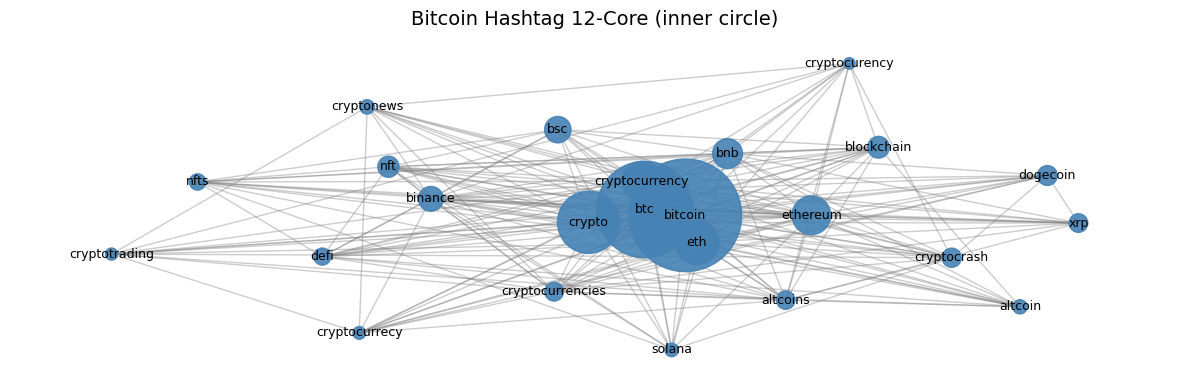

In [45]:
pos_core = nx.spring_layout(G_core, weight="weight", seed=42, k=1.5)
pr_core = {n: pagerank.get(n, 0) for n in G_core.nodes()}
sizes_core = [pr_core[n] * 30000 for n in G_core.nodes()]

plt.figure(figsize=(12,4))
nx.draw_networkx_edges(G_core, pos_core, alpha=0.4, edge_color="grey")
nx.draw_networkx_nodes(G_core, pos_core, node_size=sizes_core, node_color="steelblue", alpha=0.9)
nx.draw_networkx_labels(G_core, pos_core, {n: n for n in G_core.nodes()}, font_size=9)
plt.title(f"Bitcoin Hashtag {k_max}-Core (inner circle)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


## HITS - Hubs & Authorities
**Question answered:** *Who just broadcasts into the void vs who actually gets listened to?*

HITS computes two scores on the directed mention graph:
- **Authority** - accounts mentioned by many important hubs. High authority = genuinely influential voice.
- **Hub** - accounts that mention many important authorities. High hub score = active amplifier/broadcaster.

This is richer than raw in-degree because it considers *who* mentions you, not just *how many*. An account can have low in-degree but high authority if the few people who mention it are themselves major hubs.

In [46]:
hits_hubs, hits_auth = nx.hits(G_mention, max_iter=100, normalized=True)

hits_df = pd.DataFrame({
    "user":            list(hits_hubs.keys()),
    "hub_score":       list(hits_hubs.values()),
    "authority_score": [hits_auth[u] for u in hits_hubs],
}).sort_values("authority_score", ascending=False).reset_index(drop=True)

print("Top 5 authorities (most influential voices):")
print(hits_df[["user", "authority_score"]].head(5).to_string(index=False))
print("\nTop 5 hubs (biggest broadcasters):")
print(hits_df.sort_values("hub_score", ascending=False)[["user", "hub_score"]].head(5).to_string(index=False))


Top 5 authorities (most influential voices):
           user  authority_score
       elonmusk         0.050201
         saylor         0.033315
    peterschiff         0.018558
bitcoinmagazine         0.013783
    btc_archive         0.013232

Top 5 hubs (biggest broadcasters):
      user  hub_score
dundee boy   0.000196
 jornor193   0.000184
       jam   0.000179
         v   0.000170
  landsbay   0.000165


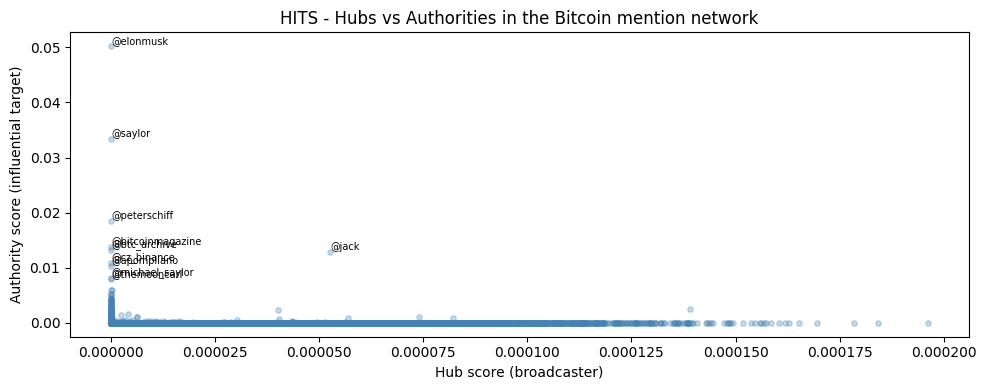

In [47]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(hits_df["hub_score"], hits_df["authority_score"], alpha=0.3, s=15, color="steelblue")
top10 = hits_df.head(10)
for _, row in top10.iterrows():
    ax.annotate(f"@{row.user}", (row.hub_score, row.authority_score), fontsize=7, ha="left", va="bottom")
ax.set_xlabel("Hub score (broadcaster)")
ax.set_ylabel("Authority score (influential target)")
ax.set_title("HITS - Hubs vs Authorities in the Bitcoin mention network")
plt.tight_layout()
plt.show()

In [48]:
jack_df = df.explode('mentions')
jack_df = jack_df[(jack_df['mentions'] == 'jack') | (jack_df.user_name == 'jack')][['user_name', 'text', 'date']]

In [49]:
print(f"number of jack's tweeted {len(jack_df[jack_df.user_name == 'jack'])}")
print(f"number of jack mentioned {len(jack_df[jack_df.user_name != 'jack']):,}")

number of jack's tweeted 14
number of jack mentioned 3,562


### HITS Analysis: (Hubs and Authorities)

The HITS (Hyperlink-Induced Topic Search) algorithm distinguishes two types of 
influential nodes in a directed network:

- **Authorities** are nodes that receive mentions from many well-connected users (trusted, high-signal voices in the community).
- **Hubs** are nodes that mention many authoritative users (broadcasters and users who drives the conversation).

The top authorities (`@elonmusk`, `@saylor`, `@peterschiff`) are consistent with in-degree rankings,\
confirming they represent genuine influence rather than coordinated mention spam.

The top hubs (e.g., `@dundee_boy`, `@jornor193`) are relatively unknown accounts with high outbound mention activity\
These people are known as "**amplifiers**," they engage with important figures but have no influence of their own.\
This gap between influence and activity is typical on social media, where a few major voices dominate while many minor accounts simply broadcast and react.

# Team Research Question:
**Question answered:** *What topics dominate each Bitcoin Twitter community, and which topics and communities drive the strongest emotional reactions?*

This section joins the Louvain community structure (from the hashtag co-occurrence network) with the LDA topic labels and VADER sentiment scores. Each tweet is assigned to the community whose hashtags appear most frequently in that tweet.

In [50]:
df_enriched = pd.read_parquet('data/bitcoin_tweet_with_topics_sentiment.parquet')
df_enriched['hashtag_list'] = df_enriched['hashtags'].apply(parse_hashtags)

print(f"Loaded {len(df_enriched):,} tweets with topic and sentiment labels")
print("\nTopics:")
print(df_enriched['topic_label'].value_counts())
print("\nSentiment distribution:")
print(df_enriched['vader_sentiment'].value_counts())

Loaded 627,360 tweets with topic and sentiment labels

Topics:
topic_label
Bitcoin as money and store of value        437662
Ethereum and altcoin discussion             56299
Crypto projects and future expectations     49425
Market cycles and price movement            42232
Buying, selling and trading behaviour       41742
Name: count, dtype: int64

Sentiment distribution:
vader_sentiment
positive    268288
neutral     210767
negative    148305
Name: count, dtype: int64


In [51]:
from collections import Counter

def assign_community(hashtag_list):
    communities = [partition[tag] for tag in hashtag_list if tag in partition]
    if not communities:
        return None
    return Counter(communities).most_common(1)[0][0]

df_enriched['community'] = df_enriched['hashtag_list'].apply(assign_community)

tagged = df_enriched['community'].notna()
print(f"Tweets mapped to a community: {tagged.sum():,} ({tagged.mean():.1%})")
print(f"Unmapped (no hashtags in network): {(~tagged).sum():,}")

df_comm = df_enriched[tagged].copy()
df_comm['community'] = df_comm['community'].astype(int)

MIN_COMM_TWEETS = 500
comm_sizes = df_comm['community'].value_counts()
valid_comms = comm_sizes[comm_sizes >= MIN_COMM_TWEETS].index
df_comm_valid = df_comm[df_comm['community'].isin(valid_comms)]
print(f"\nCommunities with >= {MIN_COMM_TWEETS} tweets: {len(valid_comms)}")

Tweets mapped to a community: 624,053 (99.5%)
Unmapped (no hashtags in network): 3,307

Communities with >= 500 tweets: 8


### 6.1 Topic Distribution per Community
Which topics dominate each community? Each row is a Louvain community; each column is an LDA topic. Values show the share of tweets in that community belonging to each topic.

In [52]:
df_comm_valid.topic_label.unique()

array(['Crypto projects and future expectations',
       'Buying, selling and trading behaviour',
       'Bitcoin as money and store of value',
       'Ethereum and altcoin discussion',
       'Market cycles and price movement'], dtype=object)

In [53]:
# make the labels shorter for visuals
topic_mapping = {
    'Crypto projects and future expectations': 'Crypto Projects',
    'Buying, selling and trading behaviour': 'Trading Behaviour',
    'Bitcoin as money and store of value': 'Bitcoin/Store of Value',
    'Ethereum and altcoin discussion': 'ETH & Altcoins',
    'Market cycles and price movement': 'Price Movement'
}

# 2. Apply it directly to the column before grouping
df_comm_valid['topic_label'] = df_comm_valid['topic_label'].map(topic_mapping)

C:\Users\batbi\AppData\Local\Temp\ipykernel_9084\644324547.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comm_valid['topic_label'] = df_comm_valid['topic_label'].map(topic_mapping)


In [54]:
pivot_topic = (
    df_comm_valid.groupby(['community', 'topic_label'])
    .size()
    .unstack(fill_value=0)
)
pivot_norm = pivot_topic.div(pivot_topic.sum(axis=1), axis=0)
pivot_norm

topic_label,Bitcoin/Store of Value,Crypto Projects,ETH & Altcoins,Price Movement,Trading Behaviour
community,,,,,
0,0.748225,0.054911,0.060992,0.064960,0.070911
2,0.160279,0.806928,0.006354,0.019471,0.006969
3,0.151302,0.756181,0.048796,0.021778,0.021942
4,0.430740,0.214421,0.027514,0.000000,0.327324
5,0.671030,0.109075,0.078534,0.084642,0.056719
6,0.879371,0.024476,0.000000,0.001748,0.094406
9,0.964824,0.026496,0.000000,0.005025,0.003655
18,0.613031,0.079282,0.167939,0.079197,0.060550


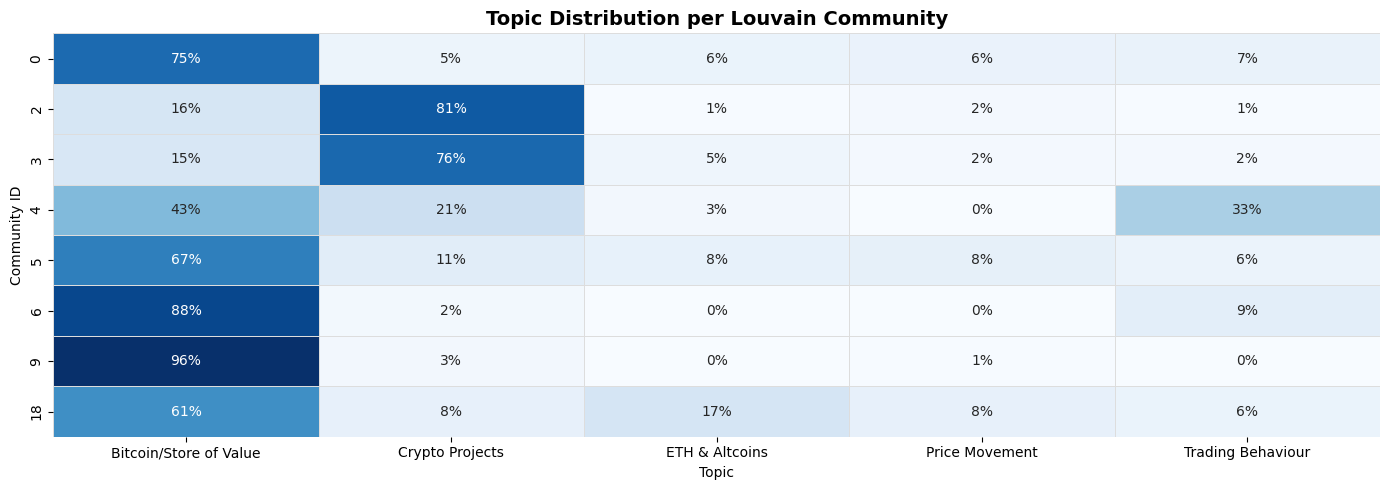

In [55]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_norm, annot=True, fmt='.0%', cmap='Blues', ax=ax,
            linewidths=0.4, linecolor='#ddd',
            cbar_kws={'label': 'Share of community tweets'},cbar=False)
ax.set_title('Topic Distribution per Louvain Community', fontsize=14, fontweight='bold')
ax.set_xlabel('Topic')
ax.set_ylabel('Community ID')
#plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

### 6.2 Average Sentiment per Community x Topic
Which community-topic combinations generate the strongest emotional reactions? Green = positive sentiment, red = negative sentiment.

In [56]:
pivot_sent = (
    df_comm_valid.groupby(['community', 'topic_label'])['vader_compound']
    .mean()
    .unstack(fill_value=np.nan)
)
pivot_sent

topic_label,Bitcoin/Store of Value,Crypto Projects,ETH & Altcoins,Price Movement,Trading Behaviour
community,,,,,
0,0.089859,0.360043,0.096705,0.061749,0.063032
2,0.298540,0.677212,0.161210,0.328891,0.288318
3,0.162813,0.566899,0.081968,0.083789,0.180439
4,0.798191,0.822053,0.697772,NaN,-0.000792
5,0.003608,0.359862,-0.080768,-0.015992,-0.043828
6,-0.406138,0.324457,NaN,0.831600,0.736674
9,-0.017971,0.350188,NaN,0.087709,-0.170637
18,0.077125,0.382991,0.112917,0.059539,0.070793


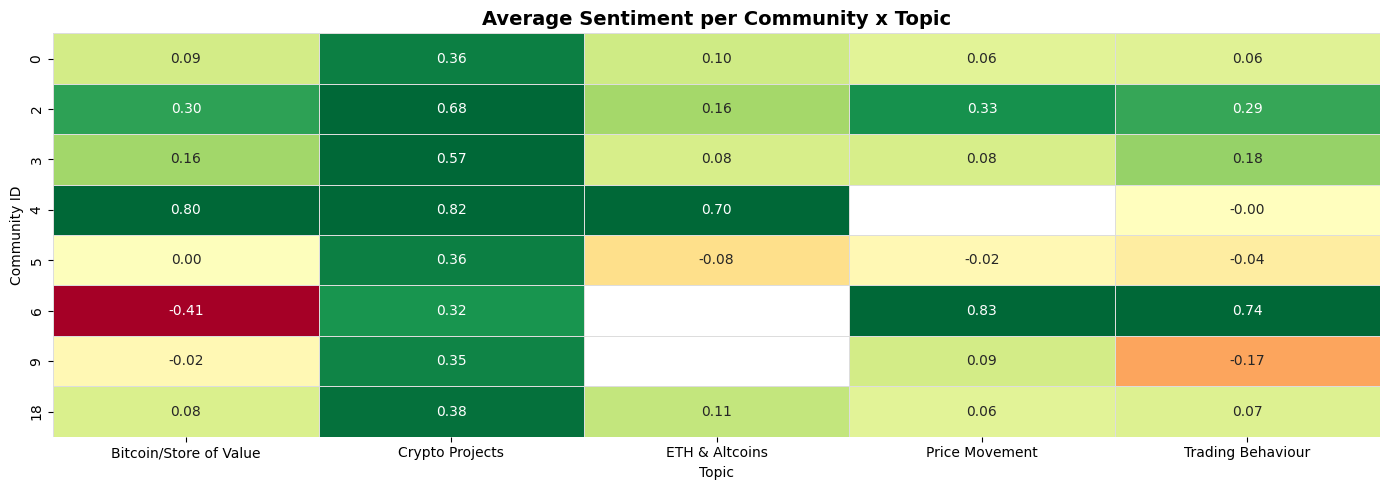

In [57]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_sent, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-0.4, vmax=0.4, ax=ax,
            linewidths=0.4, linecolor='#ddd',
            cbar_kws={'label': 'Mean VADER compound score'},cbar=False)
ax.set_title('Average Sentiment per Community x Topic', fontsize=14, fontweight='bold')
ax.set_xlabel('Topic')
ax.set_ylabel('Community ID')
#plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### 6.3 Community Sentiment Polarity
Overall average VADER compound score per community. Communities to the right of zero are net positive; left are net negative.

In [58]:
comm_sent = (
    df_comm_valid.groupby('community')['vader_compound']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'avg_sentiment', 'std': 'sentiment_std', 'count': 'tweet_count'})
    .sort_values('avg_sentiment')
)
#comm_sent = comm_sent[comm_sent.tweet_count > 500]
comm_sent

,avg_sentiment,sentiment_std,tweet_count
community,,,
6,-0.278205,0.389464,572
9,-0.008243,0.488022,2189
5,0.031491,0.468312,1146
0,0.101384,0.419157,428168
18,0.105610,0.410851,176647
3,0.463096,0.433799,6107
4,0.539018,0.406270,1054
2,0.603748,0.332214,4879


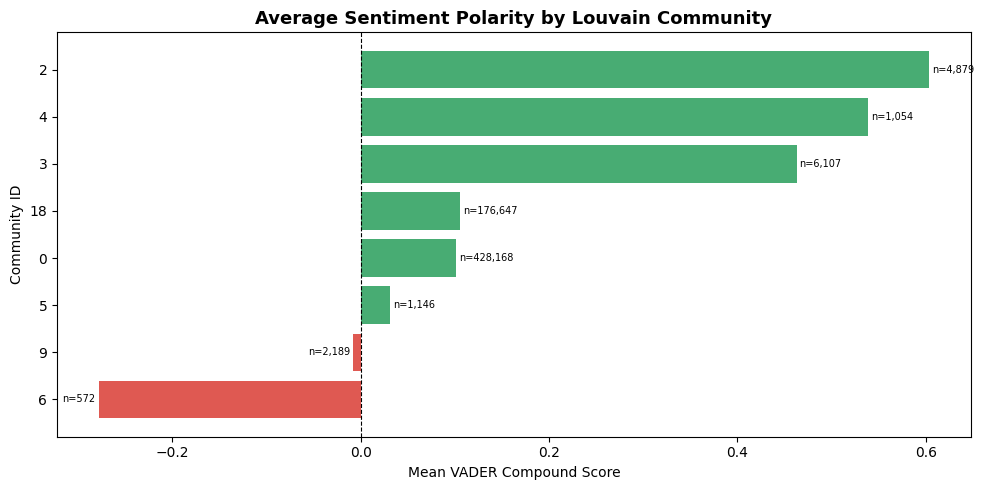

Most negative community: 6 (-0.278)
Most positive community: 2 (0.604)


In [59]:
colors = ['#d73027' if v < 0 else '#1a9850' for v in comm_sent['avg_sentiment']]

fig, ax = plt.subplots(figsize=(10, max(5, len(comm_sent) * 0.45)))
ax.barh(comm_sent.index.astype(str), comm_sent['avg_sentiment'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean VADER Compound Score')
ax.set_ylabel('Community ID')
ax.set_title('Average Sentiment Polarity by Louvain Community', fontsize=13, fontweight='bold')
for i, (idx, row) in enumerate(comm_sent.iterrows()):
    offset = 0.003 if row['avg_sentiment'] >= 0 else -0.003
    ax.text(row['avg_sentiment'] + offset, i, f"n={row['tweet_count']:,.0f}",
            va='center', ha='left' if row['avg_sentiment'] >= 0 else 'right', fontsize=7) # for the bar labels
plt.tight_layout()
plt.show()

print("Most negative community:", comm_sent['avg_sentiment'].idxmin(),
      f"({comm_sent['avg_sentiment'].min():.3f})")
print("Most positive community:", comm_sent['avg_sentiment'].idxmax(),
      f"({comm_sent['avg_sentiment'].max():.3f})")

### Key Findings
- The community-topic heatmap shows which discussion themes define each structurally detected community.
- The sentiment heatmap reveals which community-topic combinations generate the strongest emotional reactions.
- The polarity chart ranks communities from most negative to most positive overall.

## Cross-Analysis: Network Communities × Sentiment × Topics

Mapping tweet-level sentiment and topic labels back to their Louvain community reveals meaningful\
differences in how distinct hashtag communities discuss Bitcoin:

- **Community 6** (FEG/FEGtoken ecosystem) shows the most negative average sentiment **(-0.278)**,\
likely reflecting community frustration around the FEG token's poor performance and trust issues during this period.

- **Community 14** (charity/THC/TranshumanCoin) shows the most positive sentiment (0.796), consistent\
with cause-driven communities that maintain optimistic, mission-oriented discussion.

- The dominant **Community 0** (general crypto discussers) sits near neutral. It reflects the balanced mix of bullish,\
bearish prices and informational content shared, which is a characteristic of broad Bitcoin discussion.

These findings demonstrate that sentiment in Bitcoin Twitter is not uniform. Rather, it varies systematically by community,\
suggesting that the *social structure* of the network (who talks to whom, around which hashtags) is a meaningful predictor of conversational tone.

In [ ]:
df_size_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Current DataFrame size: {df_size_mb:.2f} MB")

df_sample = df.sample(9000) # used sample for get all types of data from different dates
df_size_mb = df_sample.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Sample DataFrame size: {df_size_mb:.2f} MB")

Current DataFrame size: 642.15 MB
Sample DataFrame size: 9.13 MB


In [71]:
df_sample = df_sample.sort_values('date')
df_sample.to_csv('bitcoin_tweet_sample.csv')